In [3]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
# from get_ddf import get_hourly_df
from data_handling import *
import statsmodels.api as sm
from scipy.stats import gaussian_kde as kde
import sys 
from scipy.optimize import minimize
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import *

import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/ddf/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']
coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemon_creek':'58.5_-134.3',
                'gulkana':'63.5_-145.6'}
site_dict = {
    'kahiltna':['K17b','K53'], # KAHILTNA     'KPS','K14k',
    'kennicott':['GTH','KC31','GTL'], # KENNICOTT
    'gulkana':['AU','B','D'], # GULKANA
    'wolverine':['N','B','EC'], # WOLVERINE
    'lemon_creek':['B','C','D'], # LEMON CREEK
    'taku':['MG1','NWB1','TKG3'], # TAKU
}

In [ ]:
# Get evenly spaced points on Kennicott for SAR analysis
import numpy as np
import rasterio
import geopandas as gpd
import pandas as pd
from scipy.ndimage import distance_transform_edt
from rasterio.mask import mask as riomask

def get_glacier_centerline(dem_path, glacier_gdf, elevation_step=50):
    """
    Takes a path to a DEM and a GeoDataFrame, returns points at the 
    center of the glacier at specific elevation intervals.
    """
    with rasterio.open(dem_path) as src:
        # 1. Match CRS
        if glacier_gdf.crs != src.crs:
            glacier_gdf = glacier_gdf.to_crs(src.crs)
        
        # 2. Mask and Crop
        # 'riomask' prevents the UnboundLocalError we talked about
        out_image, out_transform = riomask(src, glacier_gdf.geometry.values, crop=True)
        dem = out_image[0]
        
        # 3. Handle Nodata
        # 3. Aggressive Nodata Catch
        # Often DEMs use 0 or -9999 regardless of what the metadata says.
        # We define 'valid' as anything that isn't a common nodata value.
        valid_mask = (dem > -9000) & (dem != 0) & (np.isfinite(dem))
        
        # 4. Force the edges of the box to be 'Zero'
        # This ensures the distance transform doesn't treat the image frame as 'center'
        dist_input = np.zeros_like(dem, dtype=int)
        dist_input[valid_mask] = 1
        
        if not np.any(dist_input):
            return []

        # Now EDT will measure distance from the glacier boundary to the black background
        dist_map = distance_transform_edt(dist_input)

        if dist_map.max() == 0:
            # Fallback: if the logic is still flipped for your specific DEM nodata
            dist_map = distance_transform_edt(~valid_mask)
        
        # 5. Define Elevation Samples
        min_e = np.nanmin(dem[valid_mask])
        max_e = np.nanmax(dem[valid_mask])
        target_elevs = list(range(500, 2000, 100)) + list(range(2000, 5000, 500))
        
        centerline_points = []
        tol = elevation_step * 0.05 

        for elev in target_elevs:
            # Create a horizontal slice of the glacier
            slice_mask = (dem >= (elev - tol)) & (dem <= (elev + tol)) & valid_mask
            
            if np.any(slice_mask):
                # 1. Get distance values only for this elevation slice
                slice_distances = dist_map[slice_mask]
                
                # 2. Find the 10% 'deepest' pixels in this specific elevation band
                # This prevents picking a single noisy pixel on the boundary
                threshold = np.percentile(slice_distances, 90)
                deep_pixel_mask = slice_mask & (dist_map >= threshold)
                
                # 3. Get the average coordinates of these deepest pixels
                rows, cols = np.where(deep_pixel_mask)
                center_row, center_col = np.mean(rows), np.mean(cols)
                
                # 4. Map back to coordinates
                lon, lat = rasterio.transform.xy(out_transform, center_row, center_col)
                
                centerline_points.append({
                    'elevation': float(elev),
                    'lat': lat,
                    'lon': lon
                })
                
    return centerline_points

# Usage
# Load shapefile to DEM crs
shp = gpd.read_file('../../RGI/rgi60/01_rgi60_Alaska/01_rgi60_Alaska.shp')
shp = shp.loc[shp['RGIId'] == 'RGI60-01.15645']
points = get_glacier_centerline('../../data/dems/kennicott_dem.tif', shp, elevation_step=100)

In [27]:
site_df = pd.read_csv('../data/by_glacier/kennicott/site_constants.csv', index_col=0)

for point in points:
    elev = 'K'+str(int(point['elevation']))
    site_df.loc[elev] = [np.nan] * len(site_df.columns)
    site_df.loc[elev, 'lat'] = point['lat']
    site_df.loc[elev, 'lon'] = point['lon']
    site_df.loc[elev, 'elevation'] = point['elevation']
site_df.to_csv('../data/by_glacier/kennicott/site_constants.csv')

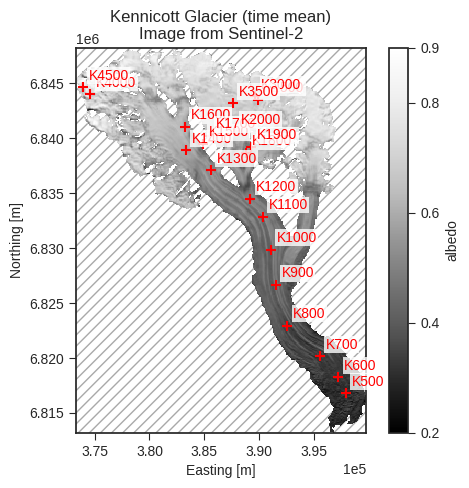

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'Kennicott Glacier (time mean)\nImage from Sentinel-2'}, xlabel='Easting [m]', ylabel='Northing [m]'>)

In [29]:
albedo = Albedo('kennicott','GTH')
new_sites = ['K'+str(int(point['elevation'])) for point in points]
albedo.plot_map(plot_sites=new_sites)

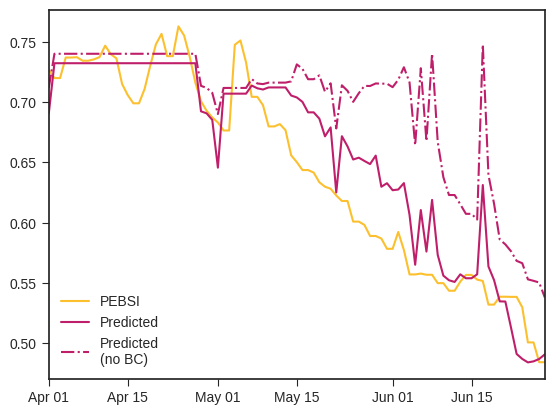

In [31]:
start, end = pd.to_datetime('2019-04-01'),pd.to_datetime('2019-06-28')
df = pd.read_csv(base_fp + 'all_snow_df_processed.csv')
df = df.loc[df['glaciersite'] == 'gulkanaB']
df.index = pd.to_datetime(df['time'])
df = df.loc[pd.date_range(start, end)]
fig, ax = plt.subplots()
ax.plot(df.index, df['albedo'], color=colors[1], label='PEBSI')
ax.plot(df.index, df['albedo_ml'], color=colors[4], label='Predicted')
ax.plot(df.index, df['albedo_ml_noBC'], color=colors[4], linestyle='-.', label='Predicted\n(no BC)')
ax.legend()
ax.tick_params(length=5)
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%b %d'))
ax.set_xlim(start, end)
plt.show()

In [ ]:
glacier = 'gulkana'
site = 'B'
snowmelt_class = SnowMelt(glacier, site)
dem_class = DEM(glacier)
albedo = Albedo(glacier, site)
dem_class.reproject_to(albedo.ds)
albedo.plot_map_snowline('2021-07-01', snowmelt_class, dem_class, snowline_var='snowline_elev_m', plot_sites=[site])

In [ ]:
# FORCE THE MODEL USING REMOTELY SENSED ALBEDO
# for glacier in site_dict:
#     for site in site_dict[glacier]:
#         albedo = Albedo(glacier, site)
#         if len(np.where(~np.isnan(albedo.data))[0]) < 10:
#             continue

#         df_all = None
#         for year in np.unique(pd.to_datetime(albedo.time).year):
#             idx_year = np.where(pd.to_datetime(albedo.time).year == year)[0]
#             df = pd.DataFrame({'albedo': albedo.data.flatten()[idx_year]}, 
#                           index=pd.to_datetime(albedo.time)[idx_year])
#             df.index = pd.to_datetime(df.index).normalize()
#             df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq='D'))
#             df = df.interpolate(method='time')

#             df.index = pd.DatetimeIndex(df.index)
            
#             df.loc[df.index.min() - pd.Timedelta(days=1),'albedo'] = 0.85
#             df.loc[df.index.max() + pd.Timedelta(days=1),'albedo'] = 0.85
#             df = df.sort_index()

#             if df_all is None:
#                 df_all = df 
#             else:
#                 df_all = pd.concat([df_all, df])

#         df_all = df_all.reindex(pd.date_range(df_all.index[0], df_all.index[-1]))
#         df_all = df_all.interpolate(method='time')
#         df_hourly = df.resample('h').ffill().sort_index()
#         plt.plot(df_all.index, df_all['albedo'])
#         # print(df_all)
#         df_all.to_csv(home_fp + f'climate_data/AWS/albedo/{glacier}{site}_S2albedo.csv')
#         # assert 1==0

In [ ]:
# FIND KP
def find_kp(k, ds, bmeas, starts, ends):
    acc_mod = []
    add_mod = []
    for start, end in zip(starts, ends):
        acc_mod.append(ds.sel(time=slice(start, end)).accum.sum().values)
        refreeze = ds.sel(time=slice(start, end)).refreeze.sum().values
        melt = -1*ds.sel(time=slice(start, end)).melt.sum().values
        add_mod.append(refreeze + melt)
    acc_mod = np.array(acc_mod)
    add_mod = np.array(add_mod)
    
    objective = np.mean(np.abs((acc_mod * k + add_mod) - np.array(bmeas)))
    return objective

all_albedo = {'mod':[], 'meas':[]}
for glacier in site_dict:
    site_fn = f'../data/by_glacier/{glacier}/site_constants.csv'
    site_df = pd.read_csv(site_fn, index_col=0)
    if 'kp' not in site_df.columns:
        site_df['kp'] = site_df['lat'].copy() * np.nan

    for site in site_dict[glacier]:
        mb = MassBalance(glacier, site, use='benchmark')
        ds = xr.open_dataset(base_fp + f'{glacier}{site}_2026_02_26_base_0.nc')

        # mb.get_model_mb(ds)
        # mb.plot_mb()
        # albedo = Albedo(glacier, site)
        # albedo.get_model_albedo(ds)
        # albedo.plot_timeseries()
        # for mod, meas in zip(albedo.mod, albedo.meas):
        #     all_albedo['mod'].append(mod)
        #     all_albedo['meas'].append(meas)

        if mb.dataset == 'seasonal':
            mb.get_model_mb(ds)
            starts = mb.period_starts[mb.idx_winter]
            ends = mb.period_ends[mb.idx_winter]
            bw_meas = mb.meas[mb.idx_winter]
            
            result = minimize(find_kp,1,
                                      method='L-BFGS-B',bounds=((0, 5),),
                                      args=(ds, bw_meas, starts, ends))
            kp = result.x[0]
            site_df.loc[site, 'kp'] = kp

            bw_mod = []
            bw_mod_kp = []
            for start, end in zip(starts, ends):
                acc = ds.sel(time=slice(start, end)).accum.sum().values
                refreeze = ds.sel(time=slice(start, end)).refreeze.sum().values
                melt = -1*ds.sel(time=slice(start, end)).melt.sum().values
                bw_mod.append(acc + refreeze + melt)
                bw_mod_kp.append(acc*kp + refreeze + melt)

            print(glacier, site, kp)
            # plt.figure(figsize=(3,3))
            # plt.plot(pd.to_datetime(ends).year, bw_meas, 'k', label='Measured')
            # plt.plot(pd.to_datetime(ends).year, bw_mod, 'k--', label='Modeled')
            # plt.plot(pd.to_datetime(ends).year, bw_mod_kp, 'r', label=f'Model with kp {kp:.3f}')
            # plt.title(glacier+' '+site)
            # plt.legend()
            # plt.show()
    # site_df.to_csv(site_fn)

kahiltna K17b 0.7023414238186757
kahiltna K53 1.7068888637879764
kennicott GTH 1.6634793010179634
kennicott KC31 1.130154191842188
kennicott GTL 1.0094549347163355
gulkana AU 2.0588026401017103
gulkana B 2.710018518732716
gulkana D 3.1900623202381246
wolverine N 0.9877200957743191
wolverine B 1.1477651719827946
wolverine EC 1.981469475081177
lemon_creek B 1.4230809067903878
lemon_creek C 1.5168359512504206
lemon_creek D 1.5903339881579404


In [38]:
acc_sites = []
for glacier in site_dict:
    for site in site_dict[glacier]:
        data = MassBalance(glacier, site, use='benchmark annual')
        if np.mean(data.data) > 0:
            acc_sites.append(glacier+site)

In [ ]:
glacier = 'gulkana'
site = 'B'
data = SnowMelt(glacier, site)
ds = xr.open_dataset(base_fp + f'{glacier}{site}_2026_02_03_base_long_0.nc')
data.get_model_snow(ds)
error = data.model_error_metric(data.mod_melt, data.sar_melt['med'], data.time, transition_type='onset')
print('Melt onset MAE:',error,'days')

error = data.model_error_metric(data.mod_snow, data.sar_snow['med'], data.time, transition_type='offset')
print('Snowline MAE:',error,'days')

In [ ]:
data.plot_snow_bool()
data.plot_melt_bool()

In [ ]:
#comparing quantile mapping approaches
# ds_lemon = xr.open_dataset(base_fp + 'takuTKG3_2026_02_15_base_qmlemonkp2_0.nc')
# ds_gulk = xr.open_dataset(base_fp + 'takuTKG3_2026_02_12_base_qmallkp2_0.nc')

coords = '58.5_-134.3'
for var in ['wind','temp','rh']:
    if var == 'wind':
        dsu = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/U2M_{coords}.nc')['U2M']
        dsv = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/V2M_{coords}.nc')['V2M']
        ds_clim = np.sqrt(np.square(dsu.values) + np.square(dsv.values))
    elif var == 'rh':
        ds_clim = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/RH2M_{coords}.nc')['RH2M'].values
    elif var == 'temp':
        ds_clim = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/T2M_{coords}.nc')['T2M'].values - 273.15
    varn = var if var != 'temp' else 'temp_0'
    df_gulk = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_gulkana_{varn}.csv')
    df_lem = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_lemon_creek_{varn}.csv')
        
    # interpolate values according to quantile mapping
    values = ds_clim
    adj_gulk = np.interp(values, df_gulk['sorted'], df_gulk['mapping'])
    adj_lem = np.interp(values, df_lem['sorted'], df_lem['mapping'])

    # plt.scatter(adj_gulk, adj_lem, s=5, alpha=0.5)
    plt.scatter(values, adj_lem, s=5, alpha=0.5,label='lemon')
    plt.scatter(values, adj_gulk, s=5, alpha=0.5,label='gulkana')
    minn = np.min([adj_gulk, adj_lem])
    maxx = np.max([adj_gulk, adj_lem])
    plt.ylabel('Original MERRA-2') # Lemon Creek adjusted')
    plt.xlabel('Adjusted') # Gulkana adjusted')
    plt.plot([minn,maxx],[minn,maxx],'k--')
    plt.legend()
    plt.title(var)
    plt.show()

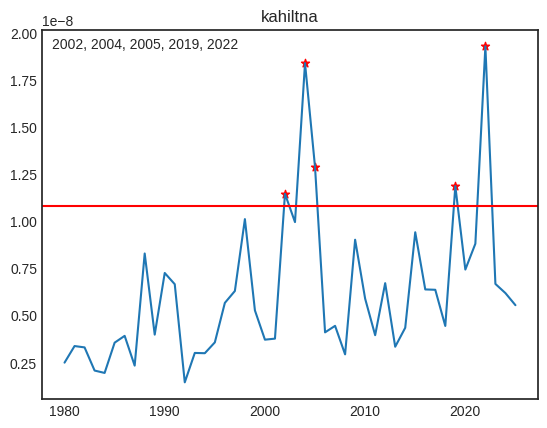

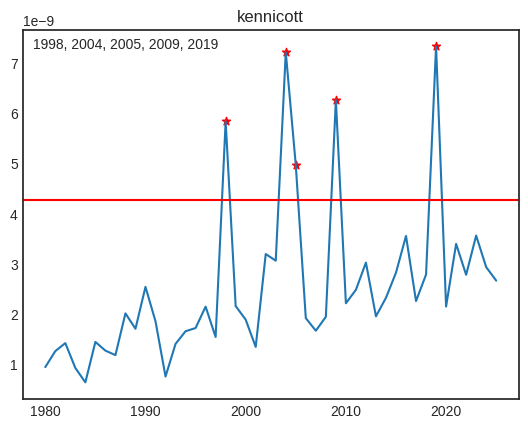

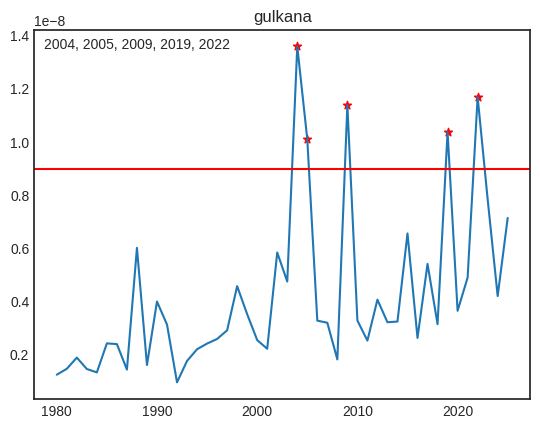

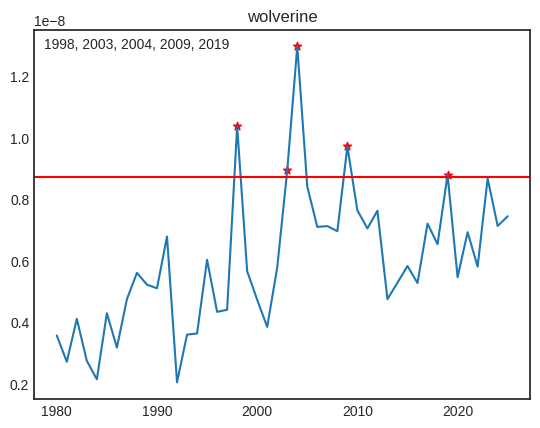

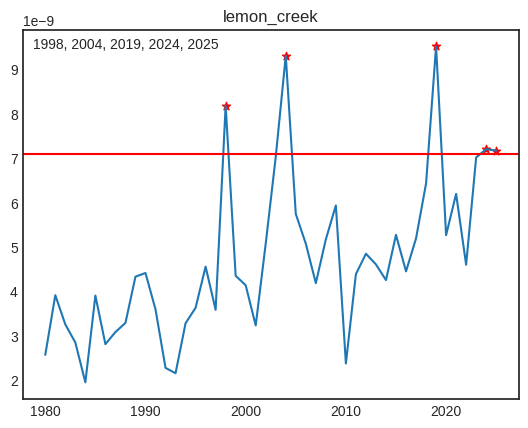

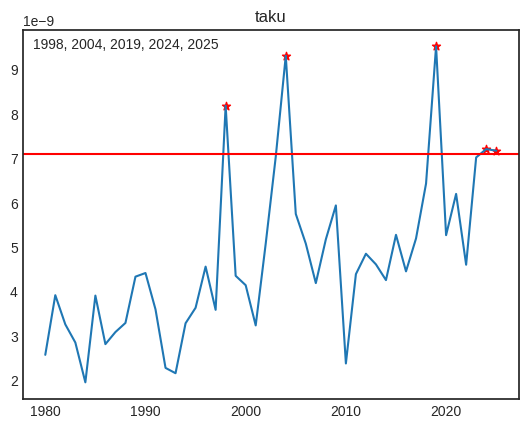

In [61]:
for glacier in site_dict:
    coords = coord_dict[glacier]
    ds = xr.open_dataset(base_fp + f'../../climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
    ds2 = xr.open_dataset(base_fp + f'../../climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
    ds['BCDP002'] = ds['BCDP002'] + ds2['BCWT002']
    # define time variables
    months = ds['time'].dt.month
    days = ds['time'].dt.day
    # create time mask from apr 1 to sep 30 (inclusive)
    mask = ((months > 3) & (months < 10))
    ds_season = ds.where(mask, drop=True)
    annual_sums = ds_season.groupby('time.year').sum()
    fig, ax = plt.subplots()
    ax.plot(annual_sums.year, annual_sums['BCDP002'].values)
    ax.axhline(np.quantile(annual_sums['BCDP002'].values, 0.90), c='r')

    threshold = np.quantile(annual_sums['BCDP002'].values, 0.90)
    base_idx = np.where(annual_sums['BCDP002'].values <= threshold)[0]
    fire_idx = np.where(annual_sums['BCDP002'].values > threshold)[0]

    fire_years = annual_sums.year.values[fire_idx]
    base_years = annual_sums.year.values[base_idx]

    ax.set_title(glacier)
    ax.scatter(annual_sums.year.values[fire_idx], annual_sums['BCDP002'].values[fire_idx], color='red', marker='*')
    ax.text(0.02, 0.95, ', '.join(fire_years.astype(str)), transform=ax.transAxes)
    plt.show()